# CERN CMS Dielectron  Notebook 1: Exploratory Data Analysis

EDA of 100k dielectron events: data quality, invariant mass spectrum, kinematic distributions, and feature correlations.

In [ ]:
#importing libraries
!pip install -q kagglehub
import kagglehub, os
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
import warnings; warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams.update({'figure.figsize':(12,5), 'font.size':12})
np.random.seed(42)

## Data Loading

In [ ]:
path = kagglehub.dataset_download('fedesoriano/cern-electron-collision-data')
df = pd.read_csv(os.path.join(path, 'dielectron.csv'))
df.columns = df.columns.str.strip()  # fix trailing spaces

Using Colab cache for faster access to the 'cern-electron-collision-data' dataset.


In [ ]:
print(f'Shape: {df.shape}')

Shape: (100000, 19)


In [ ]:
df.head()

,Run,Event,E1,px1,py1,pz1,pt1,eta1,phi1,Q1,E2,px2,py2,pz2,pt2,eta2,phi2,Q2,M
0,147115,366639895,58.71410,-7.31132,10.531000,-57.29740,12.82020,-2.20267,2.17766,1,11.2836,-1.032340,-1.88066,-11.0778,2.14537,-2.344030,-2.072810,-1,8.94841
1,147115,366704169,6.61188,-4.15213,-0.579855,-5.11278,4.19242,-1.02842,-3.00284,-1,17.1492,-11.713500,5.04474,11.4647,12.75360,0.808077,2.734920,1,15.89300
2,147115,367112316,25.54190,-11.48090,2.041680,22.72460,11.66100,1.42048,2.96560,1,15.8203,-1.472800,2.25895,-15.5888,2.69667,-2.455080,2.148570,1,38.38770
3,147115,366952149,65.39590,7.51214,11.887100,63.86620,14.06190,2.21838,1.00721,1,25.1273,4.087860,2.59641,24.6563,4.84272,2.330210,0.565865,-1,3.72862
4,147115,366523212,61.45040,2.95284,-14.622700,-59.61210,14.91790,-2.09375,-1.37154,-1,13.8871,-0.277757,-2.42560,-13.6708,2.44145,-2.423700,-1.684810,-1,2.74718


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 19 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Run     100000 non-null  int64  
 1   Event   100000 non-null  int64  
 2   E1      100000 non-null  float64
 3   px1     100000 non-null  float64
 4   py1     100000 non-null  float64
 5   pz1     100000 non-null  float64
 6   pt1     100000 non-null  float64
 7   eta1    100000 non-null  float64
 8   phi1    100000 non-null  float64
 9   Q1      100000 non-null  int64  
 10  E2      100000 non-null  float64
 11  px2     100000 non-null  float64
 12  py2     100000 non-null  float64
 13  pz2     100000 non-null  float64
 14  pt2     100000 non-null  float64
 15  eta2    100000 non-null  float64
 16  phi2    100000 non-null  float64
 17  Q2      100000 non-null  int64  
 18  M       99915 non-null   float64
dtypes: float64(15), int64(4)
memory usage: 14.5 MB


## Exploratory Data Analysis
### Data Quality

In [ ]:
print(f'Missing values: {df.isnull().sum().sum()}')
print(f'Duplicates: {df.duplicated().sum()}')
print(f'\nDtypes:\n{df.dtypes.value_counts()}')
df.describe().round(3)

Missing values: 85
Duplicates: 23

Dtypes:
float64    15
int64       4
Name: count, dtype: int64


,Run,Event,E1,px1,py1,pz1,pt1,eta1,phi1,Q1,E2,px2,py2,pz2,pt2,eta2,phi2,Q2,M
count,100000.000,1.000000e+05,100000.000,100000.000,100000.000,100000.000,100000.000,100000.000,100000.000,100000.000,100000.000,100000.000,100000.000,100000.000,100000.000,100000.000,100000.000,100000.000,99915.000
mean,147935.327,4.957212e+08,36.436,0.136,0.182,-1.508,14.412,-0.064,0.022,-0.005,44.003,-0.004,0.125,-1.591,13.802,-0.073,0.021,-0.004,30.020
std,920.306,4.037703e+08,41.216,13.405,13.470,51.604,12.389,1.462,1.800,1.000,46.751,13.127,13.169,61.430,12.461,1.738,1.817,1.000,25.256
min,146511.000,6.414000e+03,0.378,-250.587,-126.079,-840.987,0.220,-4.165,-3.142,-1.000,0.472,-233.730,-145.651,-655.396,0.027,-7.065,-3.142,-1.000,2.000
25%,147114.000,2.023970e+08,8.459,-5.234,-5.276,-15.860,3.771,-1.284,-1.527,-1.000,11.056,-4.795,-4.606,-22.037,3.738,-1.892,-1.557,-1.000,12.445
50%,147929.000,3.902759e+08,21.717,0.141,0.099,-0.313,12.968,-0.061,0.034,-1.000,25.265,-0.036,0.084,-0.690,11.691,-0.136,0.027,-1.000,21.283
75%,149011.000,6.338891e+08,50.003,5.715,5.648,13.213,20.019,1.144,1.562,1.000,66.926,4.820,5.062,19.006,19.596,1.768,1.597,1.000,39.025
max,149182.000,1.791247e+09,850.602,134.539,147.467,760.096,265.578,2.623,3.141,1.000,948.375,227.330,166.283,935.558,281.654,3.061,3.141,1.000,109.999


### Invariant Mass Spectrum
The invariant mass $M = \sqrt{(E_1+E_2)^2 - |\vec{p_1}+\vec{p_2}|^2}$ reveals parent particles:
- **J/ψ** ≈ 3.1 GeV (charmonium) | **Υ** ≈ 9.5 GeV (bottomonium) | **Z boson** ≈ 91.2 GeV (weak force carrier)

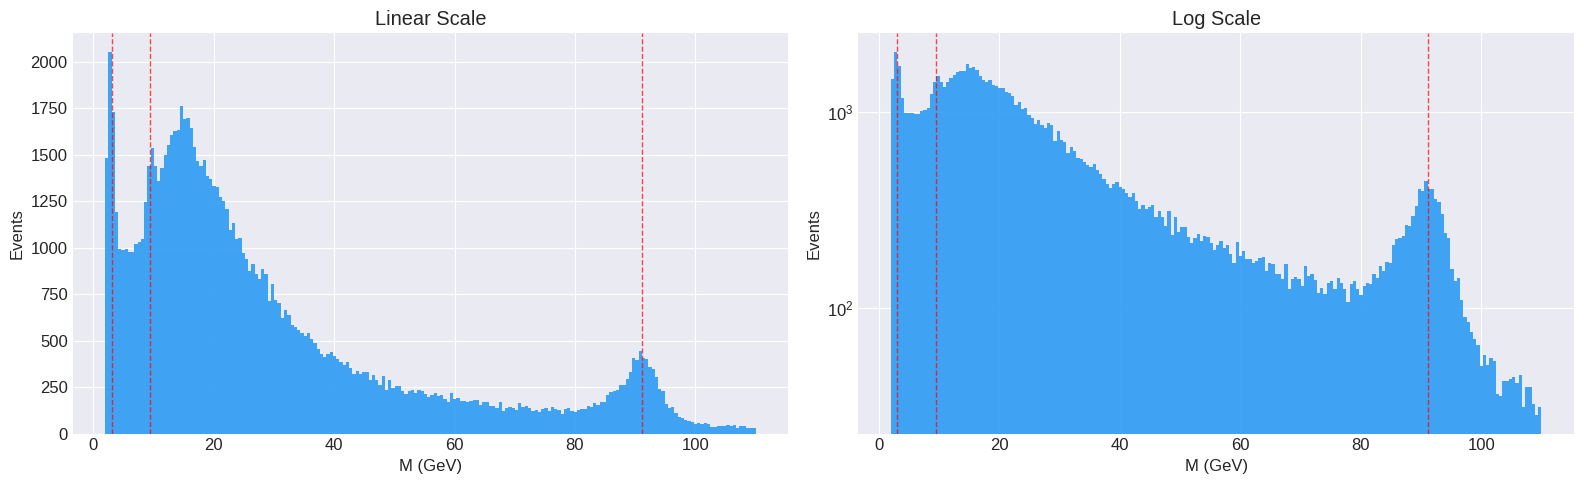

In [ ]:
#plotting M(normal as well as log scale)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, yscale in zip(axes, ['linear', 'log']):
    ax.hist(df['M'].dropna(), bins=200, color='#2196F3', edgecolor='none', alpha=0.85)
    ax.set_yscale(yscale); ax.set_xlabel('M (GeV)'); ax.set_ylabel('Events')
    for m, name in [(3.1,'J/ψ'),(9.46,'Υ'),(91.2,'Z')]:
        ax.axvline(m, color='red', ls='--', alpha=0.7, lw=1)
axes[0].set_title('Linear Scale'); axes[1].set_title('Log Scale')
plt.tight_layout(); plt.show()

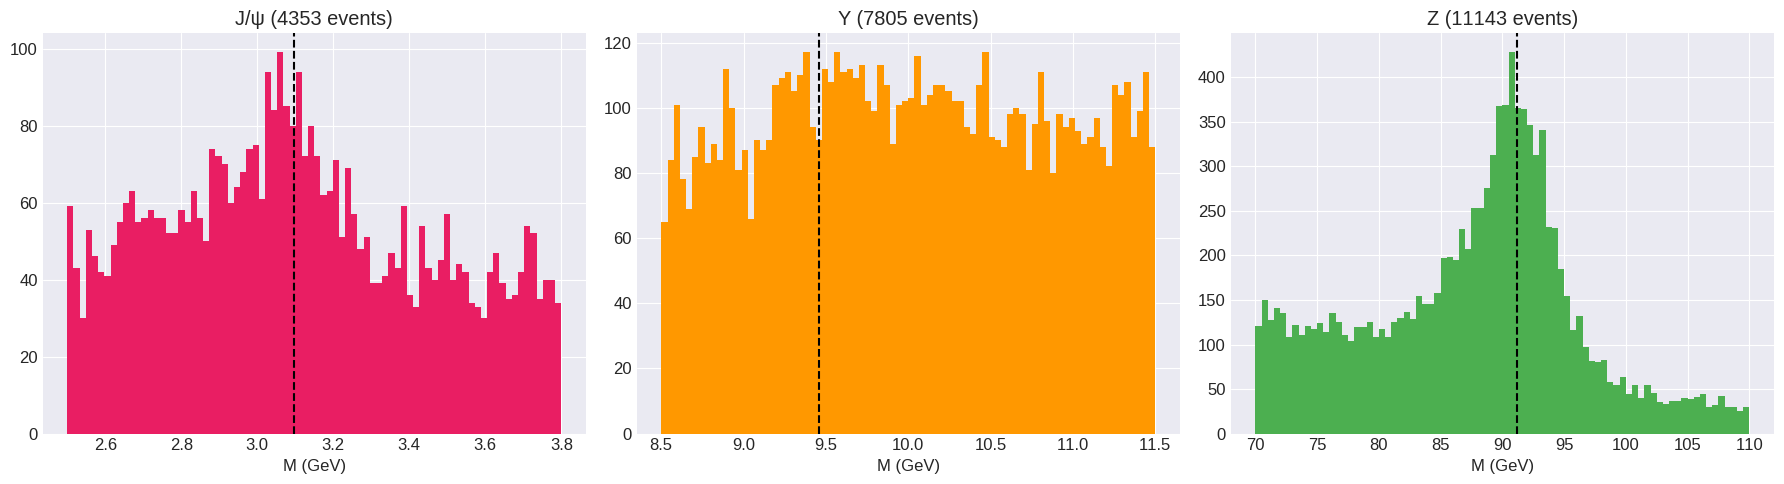

In [ ]:
# Zoomed resonance regions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name,lo,hi,peak,col) in zip(axes,
    [('J/ψ',2.5,3.8,3.096,'#E91E63'),('Υ',8.5,11.5,9.46,'#FF9800'),('Z',70,110,91.19,'#4CAF50')]):
    sub = df[(df['M']>lo)&(df['M']<hi)]
    ax.hist(sub['M'], bins=80, color=col, edgecolor='none')
    ax.axvline(peak, color='k', ls='--')
    ax.set_title(f'{name} ({len(sub)} events)'); ax.set_xlabel('M (GeV)')
plt.tight_layout(); plt.show()

### Feature Distributions

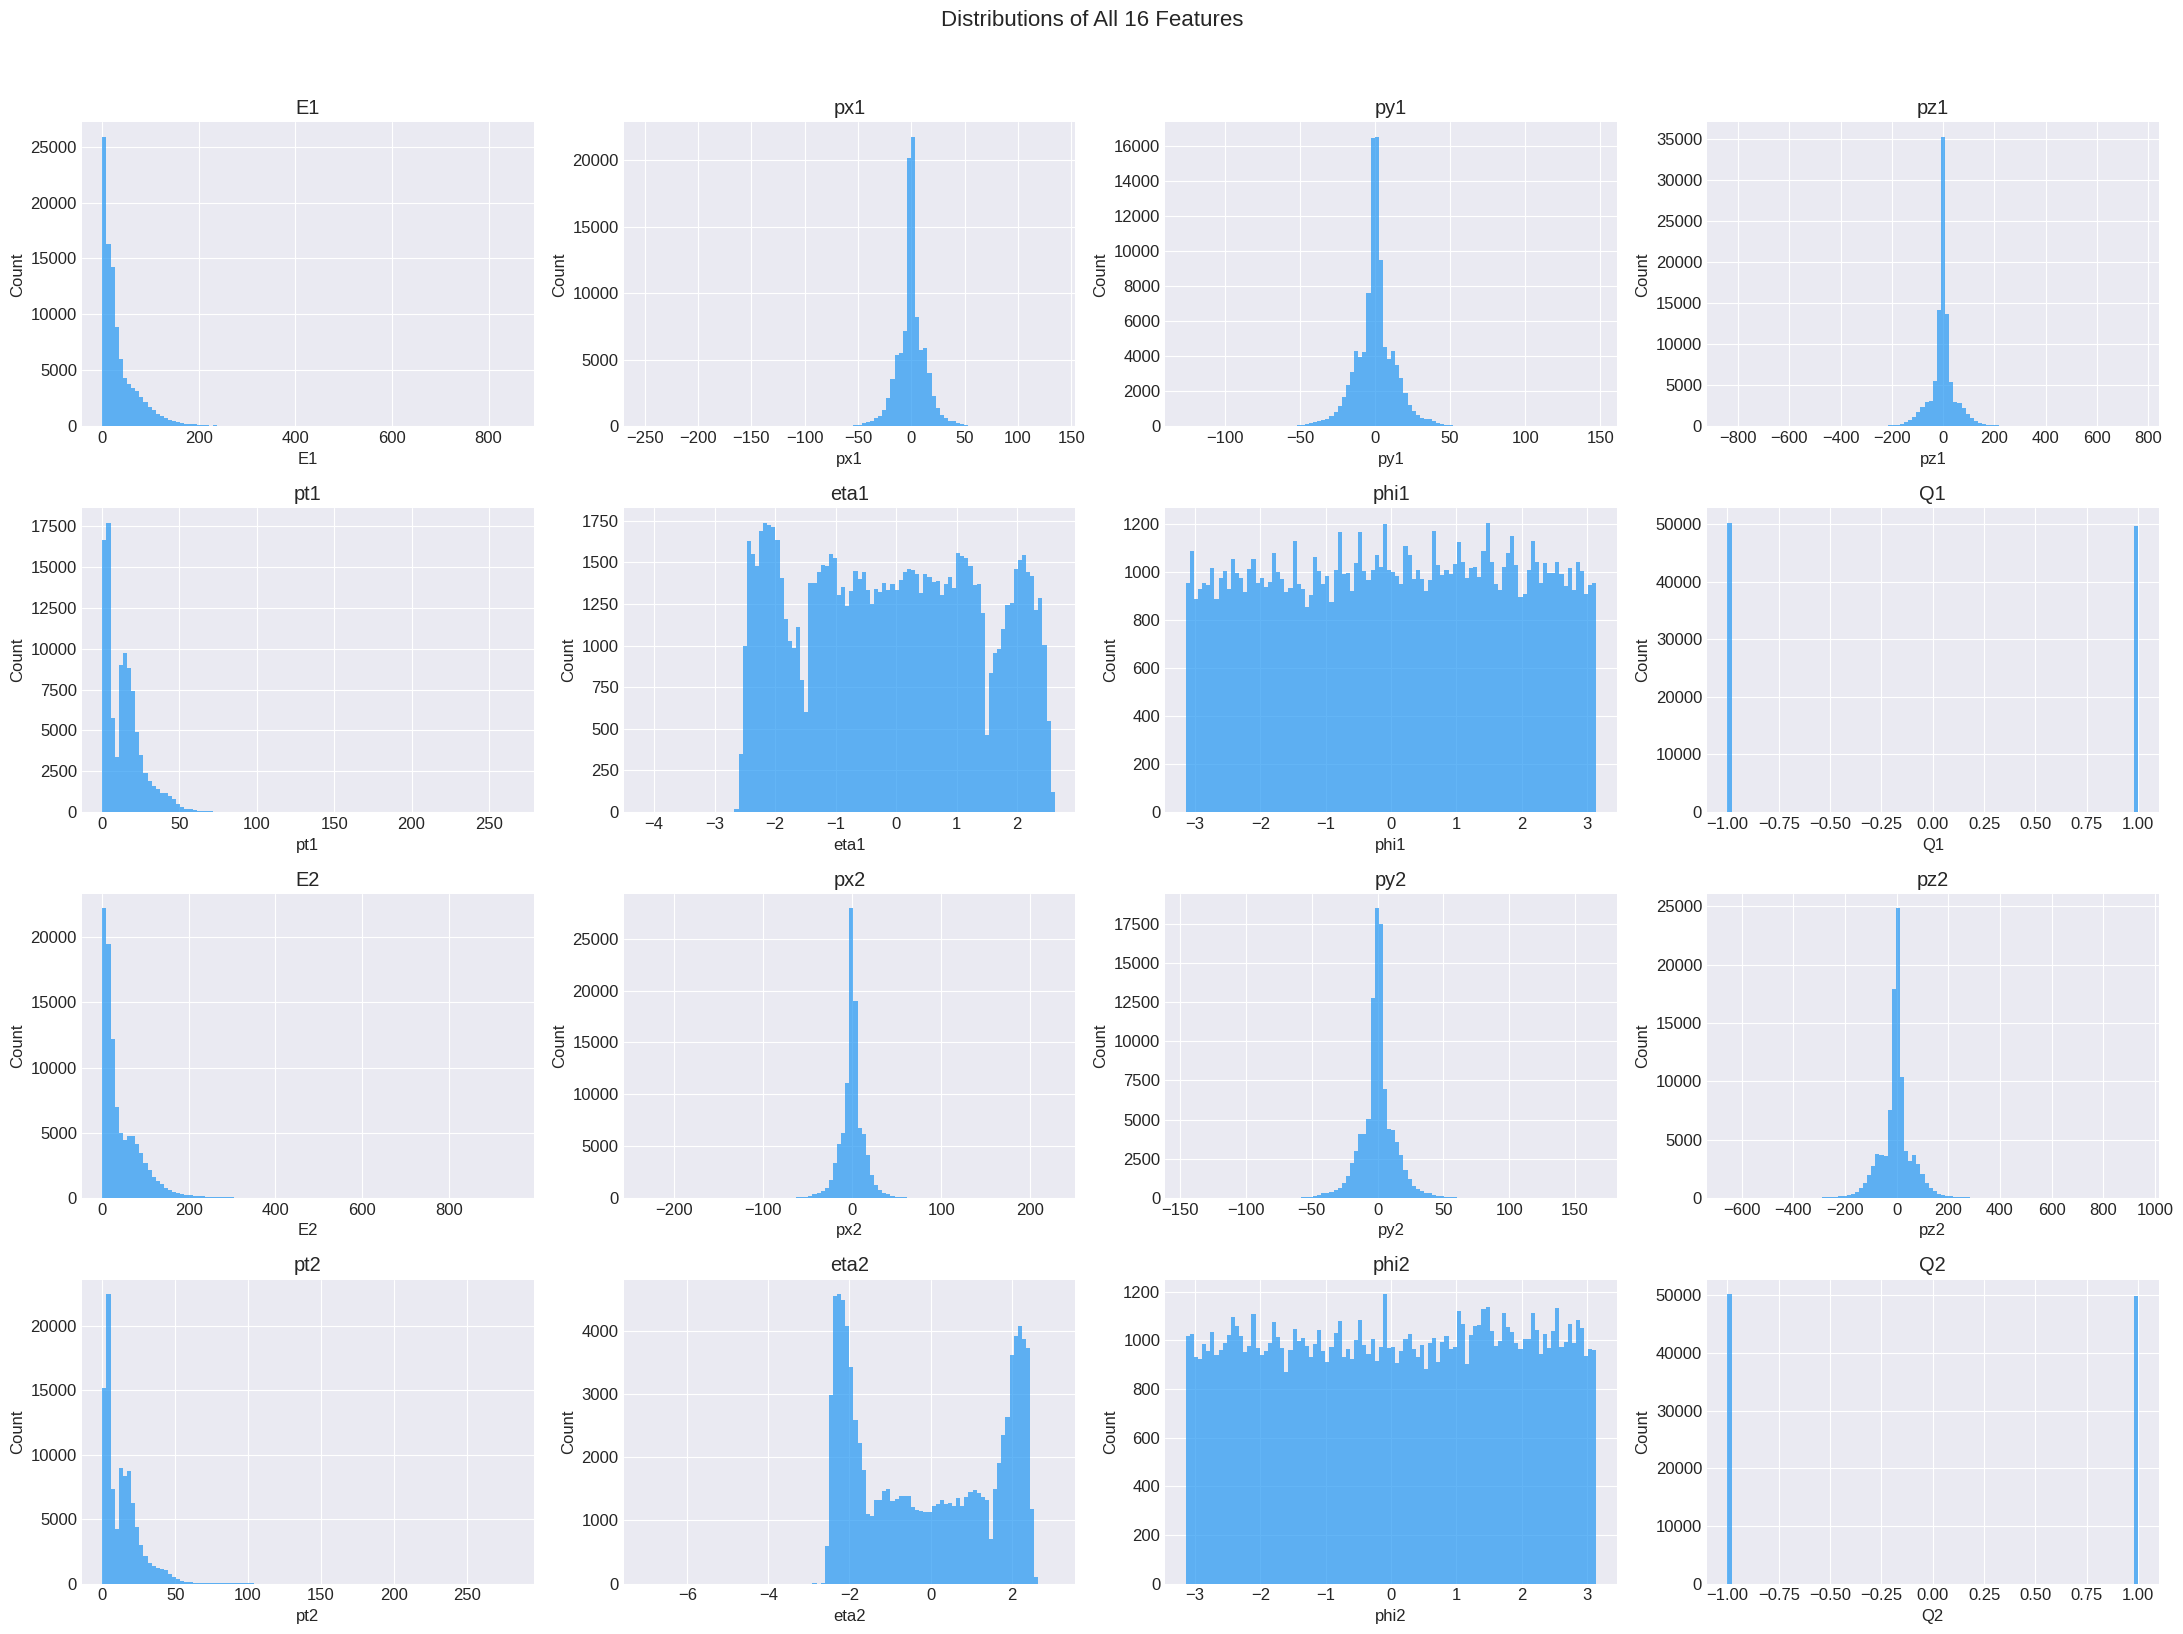

In [ ]:
all_features = [
    'E1', 'px1', 'py1', 'pz1', 'pt1', 'eta1', 'phi1', 'Q1',
    'E2', 'px2', 'py2', 'pz2', 'pt2', 'eta2', 'phi2', 'Q2'
]

fig, axes = plt.subplots(4, 4, figsize=(22, 16))

for ax, col in zip(axes.flat, all_features):
    ax.hist(df[col].dropna(), bins=100, color='#2196F3', edgecolor='none', alpha=0.7)
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel('Count')

plt.suptitle('Distributions of All 16 Features', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

### Correlation Matrix

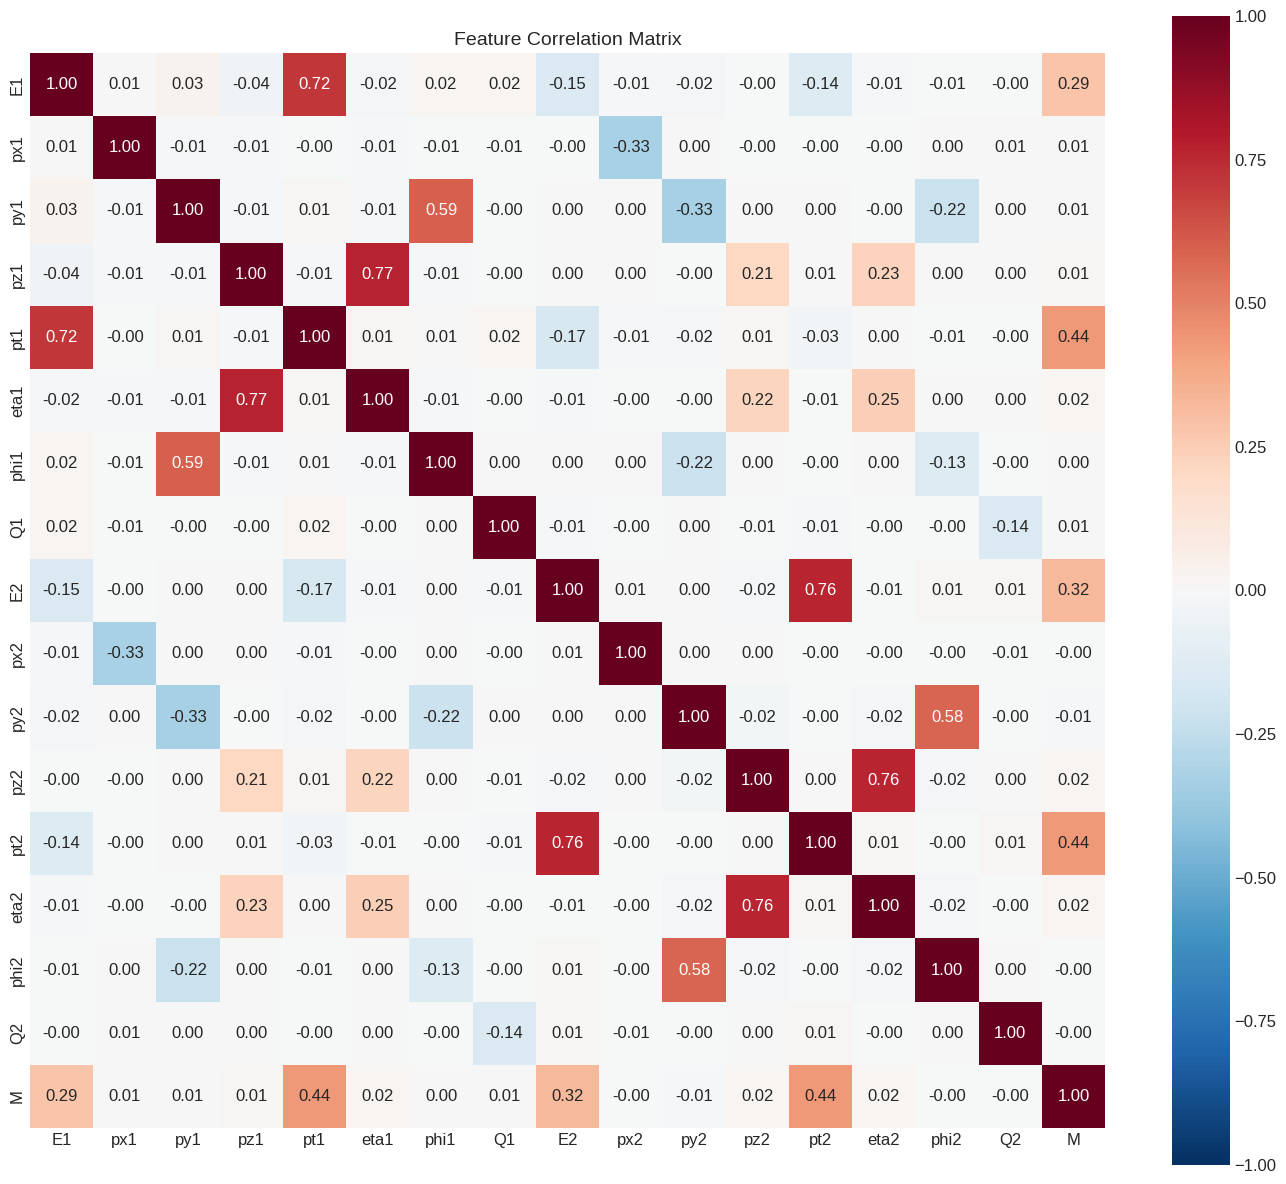

In [ ]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Remove first and second columns
numeric_cols = numeric_cols[2:]

corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, ax=ax, vmin=-1, vmax=1)

ax.set_title('Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()